# RAGAS Evaluation: Cross-Experiment Comparison

Loads results from all `experiment*/results/` folders and generates comparison charts.

**Metrics:**
- `answer_similarity` — Semantic similarity between RAG answer and ground truth
- `answer_correctness` — Factual correctness of answer vs ground truth
- `context_precision` — Are the retrieved contexts relevant?
- `context_recall` — Do contexts cover the ground truth?

In [1]:
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

EXPERIMENTS_DIR = Path(".")
METRICS = ["answer_similarity", "answer_correctness", "context_precision", "context_recall"]

## Load All Experiment Results

In [2]:
experiments = {}

for exp_dir in sorted(EXPERIMENTS_DIR.glob("experiment*/")):
    results_dir = exp_dir / "results"
    if not results_dir.exists():
        continue

    config_path = results_dir / "experiment_config.json"
    if not config_path.exists():
        continue

    with open(config_path, "r", encoding="utf-8") as f:
        config = json.load(f)

    exp_id = config.get("experiment_id", exp_dir.name)
    exp_data = {"config": config, "metrics": {}}

    # Load individual metric files (answer_similarity, answer_correctness, faithfulness)
    for mn in ["answer_similarity", "answer_correctness", "answer_relevancy", "faithfulness"]:
        mn_path = results_dir / f"{mn}.json"
        if mn_path.exists():
            with open(mn_path, "r", encoding="utf-8") as f:
                exp_data["metrics"][mn] = json.load(f)

    # Load context metrics (bundled file)
    ctx_path = results_dir / "context_metrics.json"
    if ctx_path.exists():
        with open(ctx_path, "r", encoding="utf-8") as f:
            ctx = json.load(f)
            for mn in ["context_precision", "context_recall"]:
                if mn in ctx:
                    exp_data["metrics"][mn] = ctx[mn]

    experiments[exp_id] = exp_data

print(f"Loaded {len(experiments)} experiment(s): {list(experiments.keys())}")
for exp_id, data in experiments.items():
    desc = data['config'].get('description', '')
    metrics = list(data['metrics'].keys())
    print(f"  {exp_id}: {desc}")
    print(f"    Metrics: {metrics}")

Loaded 1 experiment(s): ['experiment1']
  experiment1: Baseline: Gemma-3-27B with default prompt
    Metrics: ['answer_similarity', 'answer_correctness', 'context_precision', 'context_recall']


## Summary Table

In [3]:
rows = []
for exp_id, data in experiments.items():
    row = {
        "Experiment": exp_id,
        "Model": data["config"].get("rag_model", "?"),
    }
    for mn in METRICS:
        if mn in data["metrics"]:
            m = data["metrics"][mn]
            agg = m.get("aggregated")
            skipped = m.get("num_skipped", 0)
            scored = m.get("num_scored", 0)
            if agg is not None:
                row[mn] = f"{agg:.3f}" if isinstance(agg, float) else str(agg)
                if skipped > 0:
                    row[mn] += f" ({skipped} skipped)"
            else:
                row[mn] = "N/A"
        else:
            row[mn] = "-"
    rows.append(row)

df_summary = pd.DataFrame(rows)
pd.set_option("display.max_colwidth", 40)
print(df_summary.to_string(index=False))

 Experiment Model answer_similarity answer_correctness context_precision    context_recall
experiment1     ?             0.955 0.873 (19 skipped)             0.968 0.989 (5 skipped)


## Aggregated Scores: Bar Chart

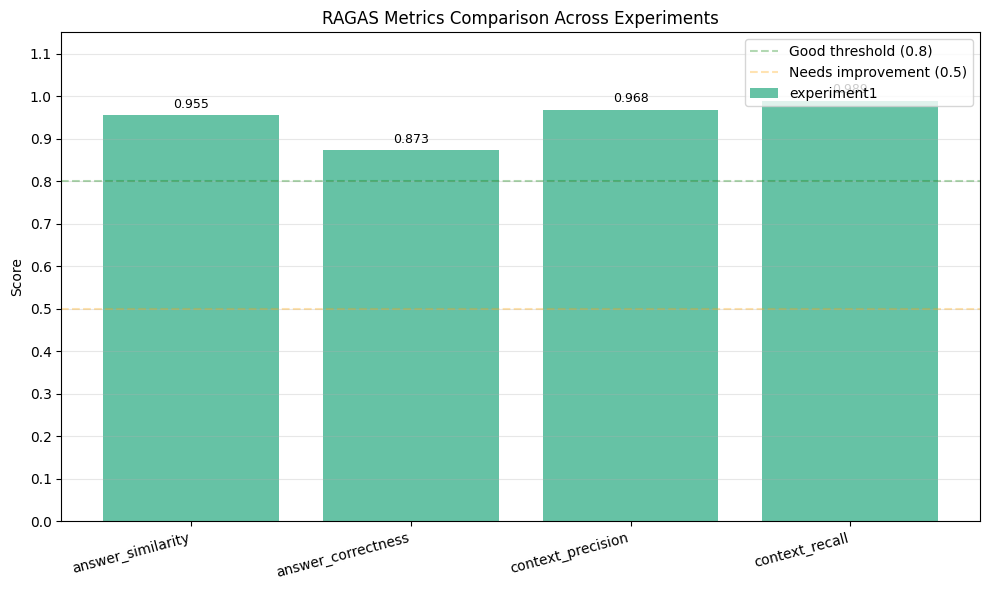

Saved comparison_bar_chart.png


In [4]:
exp_ids = list(experiments.keys())
available_metrics = []
for mn in METRICS:
    if any(mn in experiments[eid]["metrics"] and experiments[eid]["metrics"][mn].get("aggregated") is not None
           for eid in exp_ids):
        available_metrics.append(mn)

x = np.arange(len(available_metrics))
width = 0.8 / max(len(exp_ids), 1)
colors = plt.cm.Set2.colors

fig, ax = plt.subplots(figsize=(10, 6))

for i, exp_id in enumerate(exp_ids):
    values = []
    has_data = []
    for mn in available_metrics:
        m = experiments[exp_id]["metrics"].get(mn, {})
        agg = m.get("aggregated")
        if agg is not None:
            values.append(float(agg))
            has_data.append(True)
        else:
            values.append(0)
            has_data.append(False)
    offset = (i - len(exp_ids) / 2 + 0.5) * width
    bars = ax.bar(x + offset, values, width, label=exp_id, color=colors[i % len(colors)])
    for bar, val, has in zip(bars, values, has_data):
        if not has:
            bar.set_alpha(0.15)
            bar.set_hatch("//")
        elif val > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                    f"{val:.3f}", ha="center", va="bottom", fontsize=9)

ax.set_ylabel("Score")
ax.set_title("RAGAS Metrics Comparison Across Experiments")
ax.set_xticks(x)
ax.set_xticklabels(available_metrics, rotation=15, ha="right")
ax.set_ylim(0, 1.15)
ax.yaxis.set_major_locator(mticker.MultipleLocator(0.1))
ax.axhline(y=0.8, color="green", linestyle="--", alpha=0.3, label="Good threshold (0.8)")
ax.axhline(y=0.5, color="orange", linestyle="--", alpha=0.3, label="Needs improvement (0.5)")
ax.legend(loc="upper right")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("comparison_bar_chart.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved comparison_bar_chart.png")

## Radar Chart (per experiment)

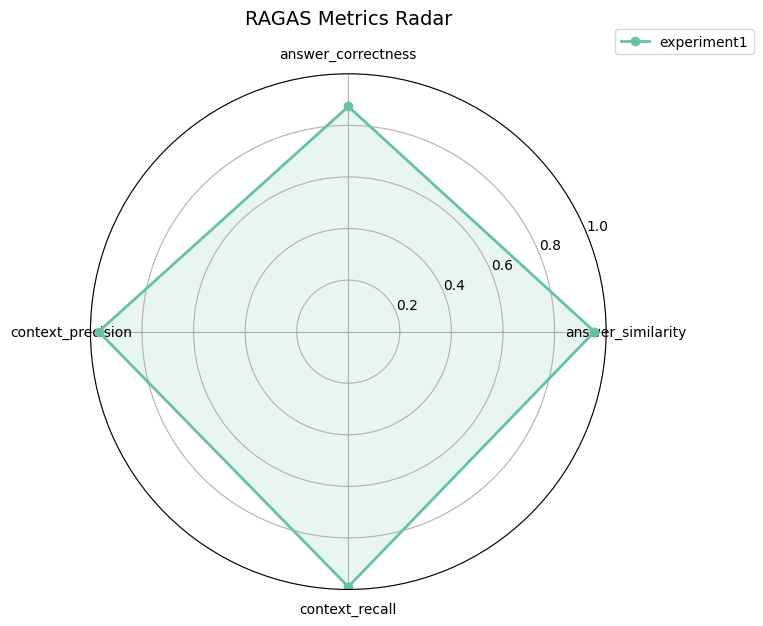

Saved comparison_radar.png


In [5]:
if len(available_metrics) >= 3:
    angles = np.linspace(0, 2 * np.pi, len(available_metrics), endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": "polar"})

    for i, exp_id in enumerate(exp_ids):
        values = []
        mask = []
        for mn in available_metrics:
            m = experiments[exp_id]["metrics"].get(mn, {})
            agg = m.get("aggregated")
            if agg is not None:
                values.append(float(agg))
                mask.append(True)
            else:
                values.append(np.nan)
                mask.append(False)
        plot_vals = [v if m else 0 for v, m in zip(values, mask)]
        plot_vals += plot_vals[:1]
        ax.plot(angles, plot_vals, "o-", linewidth=2, label=exp_id, color=colors[i % len(colors)])
        fill_vals = [v if m else 0 for v, m in zip(values, mask)]
        fill_vals += fill_vals[:1]
        ax.fill(angles, fill_vals, alpha=0.15, color=colors[i % len(colors)])
        for angle, val, has in zip(angles[:-1], values, mask):
            if not has:
                ax.plot(angle, 0, "x", color="gray", markersize=8, alpha=0.5)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(available_metrics, fontsize=10)
    ax.set_ylim(0, 1)
    ax.set_title("RAGAS Metrics Radar", y=1.08, fontsize=14)
    ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
    plt.tight_layout()
    plt.savefig("comparison_radar.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved comparison_radar.png")
else:
    print(f"Need >= 3 metrics for radar chart, only have {len(available_metrics)}")

## Per-Question Heatmap

Shows score distribution across questions for a selected experiment.

Heatmap for: experiment1


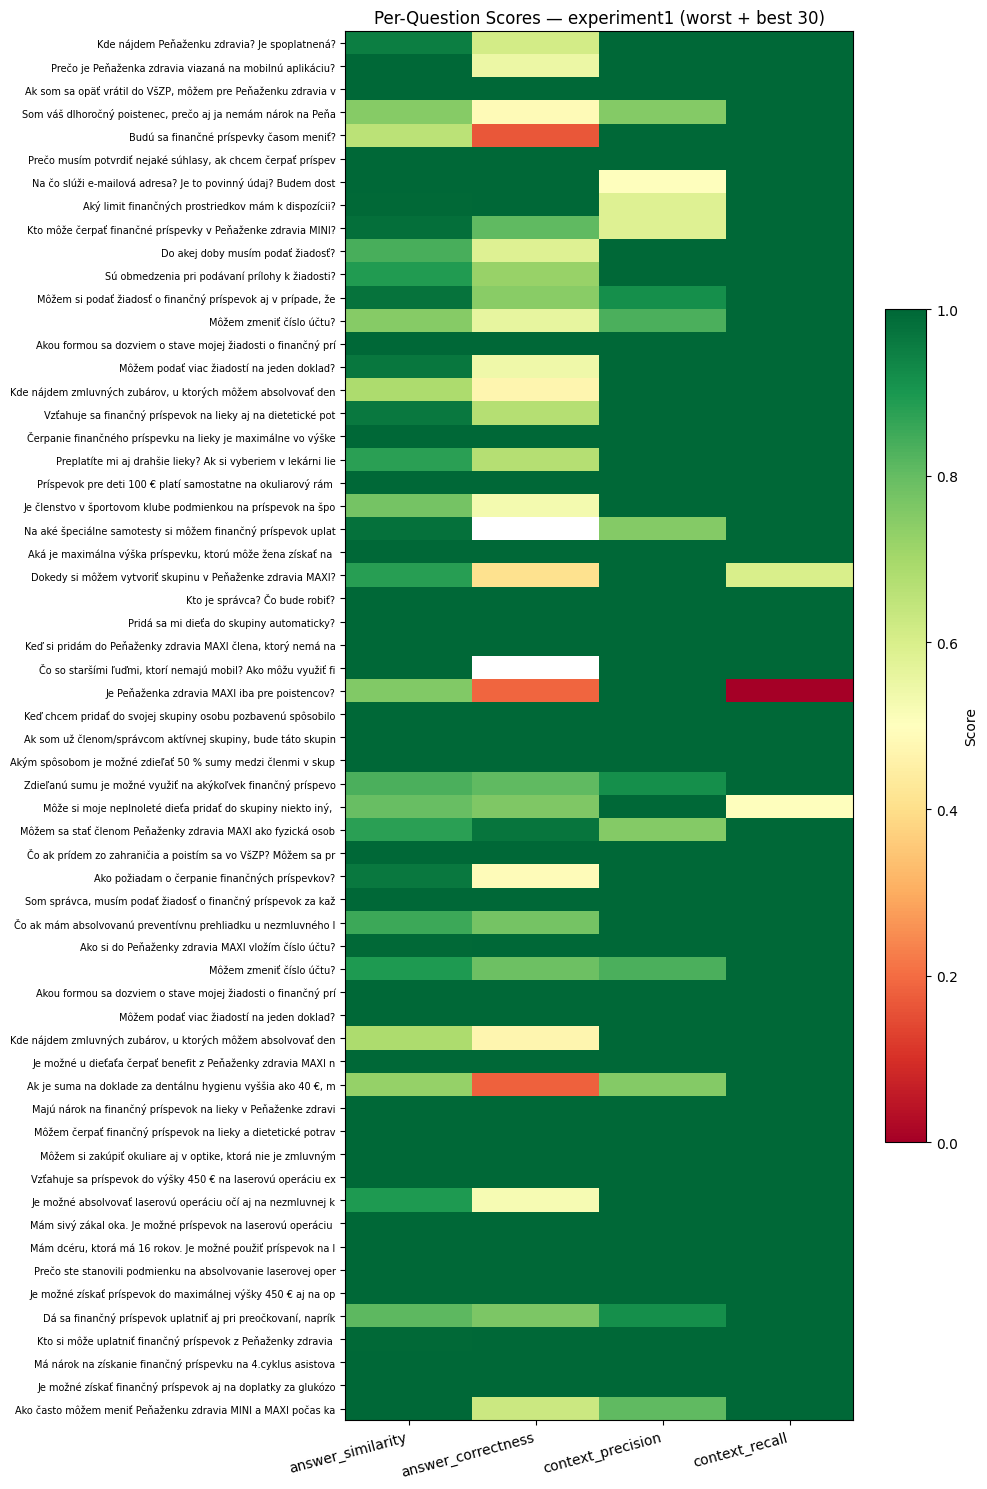

Saved comparison_heatmap.png


In [6]:
selected_exp = exp_ids[0]
print(f"Heatmap for: {selected_exp}")

exp = experiments[selected_exp]
heatmap_metrics = [mn for mn in available_metrics if mn in exp["metrics"]]

if heatmap_metrics:
    ref_metric = heatmap_metrics[0]
    questions = [q["question"][:60] for q in exp["metrics"][ref_metric]["per_question"]]
    n_questions = len(questions)

    matrix = np.full((n_questions, len(heatmap_metrics)), np.nan)
    for j, mn in enumerate(heatmap_metrics):
        pq = exp["metrics"][mn]["per_question"]
        for i in range(min(n_questions, len(pq))):
            s = pq[i].get("score")
            if s is not None:
                matrix[i, j] = s

    # Show top 30 + bottom 30 by average score for readability
    avg_scores = np.nanmean(matrix, axis=1)
    sorted_idx = np.argsort(avg_scores)
    show_count = min(30, n_questions)
    selected_idx = np.concatenate([sorted_idx[:show_count], sorted_idx[-show_count:]])
    selected_idx = np.unique(selected_idx)
    selected_idx.sort()

    fig, ax = plt.subplots(figsize=(10, max(8, len(selected_idx) * 0.25)))
    im = ax.imshow(matrix[selected_idx], aspect="auto", cmap="RdYlGn", vmin=0, vmax=1)
    ax.set_xticks(range(len(heatmap_metrics)))
    ax.set_xticklabels(heatmap_metrics, rotation=15, ha="right")
    ax.set_yticks(range(len(selected_idx)))
    ax.set_yticklabels([questions[i] for i in selected_idx], fontsize=7)
    ax.set_title(f"Per-Question Scores — {selected_exp} (worst + best {show_count})")
    plt.colorbar(im, ax=ax, shrink=0.6, label="Score")
    plt.tight_layout()
    plt.savefig("comparison_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved comparison_heatmap.png")
else:
    print("No per-question data available")

## Score Distribution (Box Plots)

/tmp/ipykernel_5083/4057178474.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True)
/tmp/ipykernel_5083/4057178474.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True)
/tmp/ipykernel_5083/4057178474.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True)
/tmp/ipykernel_5083/4057178474.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name

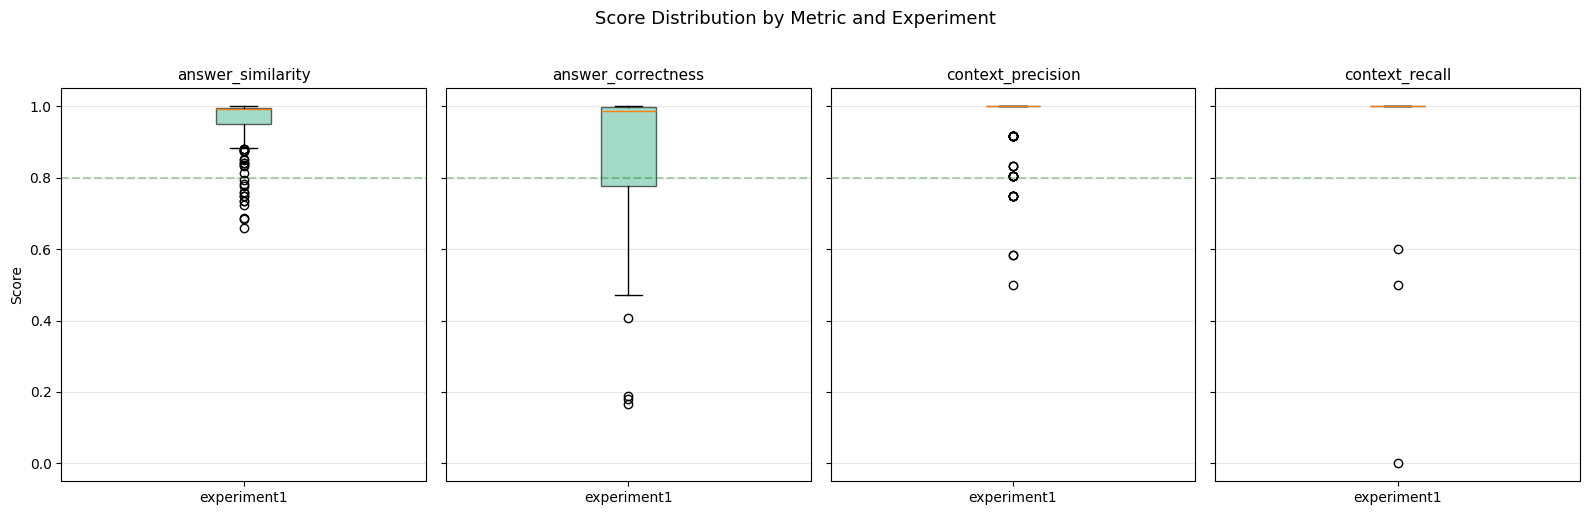

Saved comparison_boxplots.png


In [7]:
fig, axes = plt.subplots(1, len(available_metrics), figsize=(4 * len(available_metrics), 5), sharey=True)
if len(available_metrics) == 1:
    axes = [axes]

for ax, mn in zip(axes, available_metrics):
    box_data = []
    box_labels = []
    for exp_id in exp_ids:
        m = experiments[exp_id]["metrics"].get(mn, {})
        pq = m.get("per_question", [])
        scores = [q["score"] for q in pq if q.get("score") is not None]
        if scores:
            box_data.append(scores)
            box_labels.append(exp_id)

    if box_data:
        bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True)
        for patch, color in zip(bp["boxes"], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.6)
    ax.set_title(mn, fontsize=11)
    ax.set_ylim(-0.05, 1.05)
    ax.axhline(y=0.8, color="green", linestyle="--", alpha=0.3)
    ax.grid(axis="y", alpha=0.3)

axes[0].set_ylabel("Score")
fig.suptitle("Score Distribution by Metric and Experiment", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("comparison_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved comparison_boxplots.png")

## Experiment Configurations

In [8]:
config_rows = []
for exp_id, data in experiments.items():
    c = data["config"]
    config_rows.append({
        "Experiment": exp_id,
        "Description": c.get("description", ""),
        "RAG Model": c.get("rag_model", "?"),
        "Eval Model": c.get("eval_model", "?"),
        "Embedding": c.get("embedding_model", "?"),
        "Questions": c.get("num_questions", "?"),
        "Top-K": c.get("top_k", "?"),
    })

df_config = pd.DataFrame(config_rows)
pd.set_option("display.max_colwidth", 50)
print(df_config.to_string(index=False))

 Experiment                               Description RAG Model                                  Eval Model Embedding  Questions Top-K
experiment1 Baseline: Gemma-3-27B with default prompt         ? vllm-inference/Gemma-3-27B-BF16-Distributed         ?        182     ?
